# COMP8420 – Use Case 6: E-commerce Intelligent System
## Advanced NLP/LLM Project – Google Colab

**Advanced Techniques Implemented:**
1. LLM Foundation Model (Llama 3.1 via Groq)
2. Retrieval Augmented Generation (RAG)
3. Prompting Engineering + Chain-of-Thought (CoT)
4. Agentic Design

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews)



## ⚙️ Step 1 – Install Dependencies
Run this once at the start of every Colab session.

In [ ]:
!pip install groq sentence-transformers chromadb scikit-learn matplotlib seaborn -q
print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

## ⚙️ Step 2 – Groq API Key
Get your **free** key at https://console.groq.com → API Keys → Create
Paste it below. Do not share this key publicly.

In [ ]:
from groq import Groq

GROQ_API_KEY = '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'  
client     = Groq(api_key=GROQ_API_KEY)
MODEL_NAME = 'llama-3.1-8b-instant'

def call_llama(prompt, system_prompt=None, temperature=0.3):
    """
    Sends a prompt to Llama 3.1 via Groq cloud API.
    Used by all 4 advanced technique sections below.
    """
    messages = []
    if system_prompt:
        messages.append({'role': 'system', 'content': system_prompt})
    messages.append({'role': 'user', 'content': prompt})
    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=temperature,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f'Groq API error: {e}')
        return None

print(f'Groq ready. Model: {MODEL_NAME}')


Groq ready. Model: llama-3.1-8b-instant


## ⚙️ Step 3 – Load Data from Google Drive
Upload your 3 CSV files to a folder in Google Drive first.
Then update `DATA_DIR` below to match your folder path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Change this to your folder path ──────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/COMP8420_data/'
# ─────────────────────────────────────────────────────────────────────

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, re, json, warnings
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import chromadb
warnings.filterwarnings('ignore')

df1 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df2 = pd.read_csv(DATA_DIR + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df3 = pd.read_csv(DATA_DIR + '1429_1.csv', low_memory=False)
print(f'Loaded: {len(df1)+len(df2)+len(df3):,} total reviews across 3 datasets')

Mounted at /content/drive
Loaded: 67,992 total reviews across 3 datasets


## ⚙️ Step 4 – Merge & Clean Data


In [ ]:
# Columns that exist across all 3 datasets
common_cols = ['name', 'brand', 'categories', 'primaryCategories',
               'reviews.rating', 'reviews.text', 'reviews.title',
               'reviews.username', 'reviews.numHelpful', 'reviews.doRecommend']

def safe_select(df, cols):
    """Select only columns that exist in the dataframe."""
    return df[[c for c in cols if c in df.columns]].copy()

df_all = pd.concat([safe_select(d, common_cols) for d in [df1, df2, df3]], ignore_index=True)
df_all.rename(columns={
    'reviews.rating':      'rating',
    'reviews.text':        'review_text',
    'reviews.title':       'review_title',
    'reviews.username':    'username',
    'reviews.numHelpful':  'helpful_votes',
    'reviews.doRecommend': 'recommends'
}, inplace=True)

df_all.dropna(subset=['review_text', 'rating'], inplace=True)
df_all['rating']      = pd.to_numeric(df_all['rating'], errors='coerce')
df_all['review_text'] = df_all['review_text'].astype(str).str.strip()
df_all['name'] = df_all['name'].astype(str).str.strip()
df_all['name'] = df_all['name'].str.split(',,,').str[0].str.strip()
df_all = df_all[df_all['name'].str.lower() != 'nan']
df_all['word_count']  = df_all['review_text'].apply(lambda x: len(x.split()))
df_all.dropna(subset=['rating'], inplace=True)
df_all = df_all[df_all['word_count'] >= 10].reset_index(drop=True)

print(f'Combined dataset: {len(df_all):,} reviews | {df_all["name"].nunique()} unique products')
print(f'Rating distribution:')
print(df_all['rating'].value_counts().sort_index().to_string())

Combined dataset: 53,020 reviews | 111 unique products
Rating distribution:
rating
1.0     1188
2.0      888
3.0     2416
4.0    12919
5.0    35609


---
# Advanced Technique 1: LLM Foundation Model (Llama 3.1)

Uses Llama 3.1 as the core generation engine for:
- **Review summarisation** – balanced summary per product
- **Product description generation** – marketing copy from positive reviews
- **Business insight generation** – cross-product seller recommendations
- **Evaluation** – TF-IDF coverage + Unigram Recall (ROUGE-1 proxy)

In [ ]:
# Select top 6 products by review count for analysis
top_products = df_all['name'].value_counts().head(6).index.tolist()
df_work      = df_all[df_all['name'].isin(top_products)].copy()

print('Selected products:')
for i, p in enumerate(top_products, 1):
    count = len(df_work[df_work['name'] == p])
    avg   = df_work[df_work['name'] == p]['rating'].mean()
    print(f'  {i}. {p[:65]:<65} | {count:>5} reviews | avg {avg:.2f}★')

Selected products:
  1. Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Ma | 10503 reviews | avg 4.45★
  2. AmazonBasics AAA Performance Alkaline Batteries (36 Count)        |  4275 reviews | avg 4.24★
  3. Echo (White)                                                      |  3179 reviews | avg 4.64★
  4. Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Pap |  3057 reviews | avg 4.75★
  5. Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proo |  2975 reviews | avg 4.52★
  6. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes S |  2703 reviews | avg 4.58★


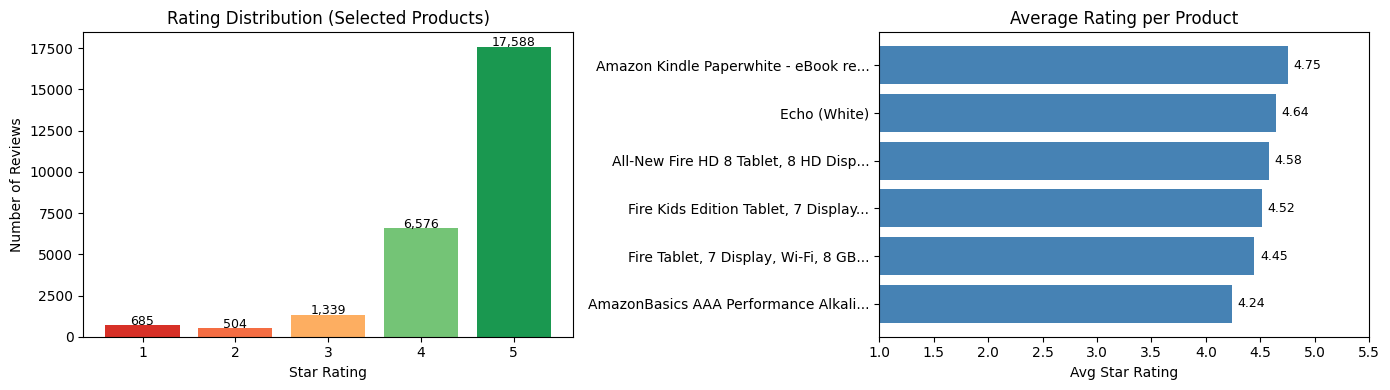

In [ ]:
# Rating distribution overview
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rating_counts = df_work['rating'].value_counts().sort_index()
colors = ['#d73027','#f46d43','#fdae61','#74c476','#1a9850']
axes[0].bar(rating_counts.index.astype(float).astype(int), rating_counts.values, color=colors)
axes[0].set_title('Rating Distribution (Selected Products)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for x, y in zip(rating_counts.index.astype(float).astype(int), rating_counts.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', fontsize=9)

avg_ratings  = df_work.groupby('name')['rating'].mean().sort_values()
short_names  = [n[:35] + '...' if len(n) > 35 else n for n in avg_ratings.index]
axes[1].barh(short_names, avg_ratings.values, color='steelblue')
axes[1].set_title('Average Rating per Product')
axes[1].set_xlabel('Avg Star Rating')
axes[1].set_xlim(1, 5.5)
for i, v in enumerate(avg_ratings.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nb1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.1 Review Summarisation

In [ ]:
def sample_reviews_for_product(df, product_name, n_pos=4, n_neg=3, n_mid=2):
    """
    Samples a balanced mix of positive, negative and neutral reviews.
    Ensures the summary reflects the full range of customer opinions.
    """
    prod_df  = df[df['name'] == product_name].copy()
    positive = prod_df[prod_df['rating'] >= 4].sample(min(n_pos, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
    negative = prod_df[prod_df['rating'] <= 2].sample(min(n_neg, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
    middle   = prod_df[prod_df['rating'] == 3].sample(min(n_mid, len(prod_df[prod_df['rating'] == 3])), random_state=42)
    return pd.concat([positive, negative, middle])['review_text'].tolist()


def summarise_product_reviews(product_name, reviews_list):
    """Sends sampled reviews to Llama for structured 4-section summarisation."""
    truncated    = [r[:200] for r in reviews_list]
    reviews_block = '\n'.join([f'[Review {i+1}]: {r}' for i, r in enumerate(truncated)])
    system = 'You are a professional product analyst. Summarise customer reviews accurately and concisely.'
    prompt = f"""Product: {product_name[:80]}

Customer Reviews:
{reviews_block}

Write a structured summary with exactly these 4 sections:
1. Overall Sentiment
2. Key Positives
3. Key Negatives
4. Verdict (1-2 sentences)

Base your answer only on the reviews above."""
    return call_llama(prompt, system_prompt=system, temperature=0.3)


summaries = {}
for product in top_products:
    print(f'Summarising: {product[:60]}...')
    reviews          = sample_reviews_for_product(df_work, product)
    summary          = summarise_product_reviews(product, reviews)
    summaries[product] = summary
    display(Markdown(f'### {product[:70]}'))
    display(Markdown(summary or '*No summary*'))
    print('-' * 60)

Summarising: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer...


### Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Structured Summary**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 4 positive reviews and 4 negative reviews. However, the positive reviews seem to outweigh the negative ones, suggesting that the product is generally well-received.

**2. Key Positives**
- The parental control and profile features are highly praised for their effectiveness in monitoring children's online activity.
- The tablet's display and reading resolution are commended for their quality.
- The price is considered "awesome" and a good value for the product.
- The tablet is suitable for young children and is a good starter device.

**3. Key Negatives**
- Some users experience freezing issues, including when watching movies.
- The tablet can be slow and unreliable.
- It no longer supports ultraviolet format, which may be a drawback for users who rely on this feature.
- The sound quality is not as good as the older Kindle Fire HD model.

**4. Verdict**
The Fire Tablet, 7 Display, Wi-Fi, 8 GB is a decent product that is suitable for young children and offers good value for its price. However, users should be aware of potential issues with freezing and sound quality.

------------------------------------------------------------
Summarising: AmazonBasics AAA Performance Alkaline Batteries (36 Count)...


### AmazonBasics AAA Performance Alkaline Batteries (36 Count)

...

**Structured Summary**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with 4 positive reviews and 4 negative reviews. However, the positive reviews seem to outweigh the negative ones, suggesting that the product is generally well-received by customers.

**2. Key Positives**
Key positives of the Fire Kids Edition Tablet include:
- Provides a sense of independence for kids
- Offers a fun and engaging learning experience
- Includes a valuable cartoon membership
- Durable and kid-proof design
- Suitable for little kids

**3. Key Negatives**
Key negatives of the Fire Kids Edition Tablet include:
- Some users experienced issues with the touch screen quality
- Poor sound quality
- Freezing issues
- Slow performance
- Some units may not turn on or charge

**4. Verdict**
The Fire Kids Edition Tablet seems to be a good option for parents looking for a durable and kid-friendly tablet, but may require some adjustments to the sound quality and performance. However, the benefits of the product, such as its durability and learning features, outweigh its drawbacks for many customers.

------------------------------------------------------------
Summarising: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Inclu...


### All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia

**Summary of Customer Reviews for All-New Fire HD 8 Tablet**

**1. Overall Sentiment**
The overall sentiment of the customer reviews is mixed, with some customers expressing satisfaction with the product's user-friendliness and performance, while others have experienced issues with charging, performance, and app availability.

**2. Key Positives**
Key positives mentioned by customers include:
- User-friendly interface, making it easy for non-tech friendly individuals to navigate.
- Good performance, with some customers experiencing no issues at all.
- Affordable price, with customers feeling that they get what they pay for.

**3. Key Negatives**
Key negatives mentioned by customers include:
- Issues with charging, with some customers experiencing problems even after trying new chargers.
- Performance issues, such as lagging and slow loading times.
- Limited app availability, with some customers feeling that the tablet doesn't have as many apps as Google Play.

**4. Verdict**
The All-New Fire HD 8 Tablet is a decent option for those looking for an affordable tablet with a user-friendly interface, but customers may experience issues with performance and app availability. While some customers have been satisfied with the product, others have experienced significant problems that may deter potential buyers.

------------------------------------------------------------


### 1.2 Product Description Generation

In [ ]:
def generate_product_description(product_name, positive_reviews):
    """Generates marketing copy from top positive reviews."""
    review_block = '\n'.join([f'- {r[:180]}' for r in positive_reviews[:5]])
    system = 'You are a professional e-commerce copywriter. Write honest, engaging product descriptions.'
    prompt = f"""Product: {product_name[:80]}
What customers love:
{review_block}

Write a product description (100-150 words) for an Amazon listing.
Structure: Hook → 3-4 key features → call to action.
Do NOT invent features not mentioned."""
    return call_llama(prompt, system_prompt=system, temperature=0.5)


descriptions = {}
for product in top_products:
    pos_reviews = df_work[(df_work['name'] == product) & (df_work['rating'] >= 4)]['review_text'].head(5).tolist()
    if pos_reviews:
        print(f'Generating: {product[:55]}...')
        desc = generate_product_description(product, pos_reviews)
        descriptions[product] = desc
        display(Markdown(f'**{product[:70]}**'))
        display(Markdown(desc or '*No description*'))
        print()

Generating: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special ...


**Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta**

**Unlock a World of Reading with Our Fire Tablet**

Are you looking for a simple and reliable eReader that won't break the bank? Look no further. Our Fire Tablet, 7 Display, Wi-Fi, 8 GB is the perfect choice for anyone who wants to enjoy their favorite books, magazines, and more without the hassle of complicated technology.

With our Fire Tablet, you can:

* Enjoy a 7-inch display that's perfect for reading on the go
* Access a wide selection of books, magazines, and more through Wi-Fi connectivity
* Store up to 8 GB of your favorite content, so you can take it with you wherever you go
* Enjoy long-lasting battery life, so you don't have to worry about recharging every day

Try our Fire Tablet today and discover a new world of reading convenience.


Generating: AmazonBasics AAA Performance Alkaline Batteries (36 Cou...


**AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

...

**Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas**

**Introducing the Ultimate Kid-Friendly Tablet: Fire Kids Edition**

Are you looking for a tablet that's both fun and educational for your little ones? Look no further than the Amazon Fire Kids Edition tablet. Our customers rave about this device, saying it's perfect for kids who love to learn and play.

**Key Features:**

* A 7-inch display that's perfect for little hands to hold and navigate
* Wi-Fi connectivity for seamless access to thousands of child-friendly e-books, TV shows, games, and educational apps
* 16 GB of storage, ideal for storing their favorite games and apps
* A green kid-proof case that protects the tablet from drops and scratches

**Get your child's favorite tablet today!** Order now and give your child a world of learning and entertainment at their fingertips.


Generating: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - ...


**All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia**

**Unlock Endless Possibilities with the All-New Fire HD 8 Tablet**

Are you looking for a reliable and affordable tablet for yourself or your loved ones? Look no further than the All-New Fire HD 8 Tablet. With its 8-inch HD display, you'll enjoy crisp and vibrant visuals that bring your favorite content to life.

This tablet is perfect for beginners and experienced users alike, offering a seamless user experience that's easy to navigate. Plus, with 16 GB of storage, you'll have ample space to store your favorite apps, games, and books.

As an Amazon Prime member, you'll get the most out of this tablet, with easy access to a vast library of content, including movies, TV shows, music, and more. With parental controls, you can also rest assured that your kids are accessing safe and suitable content. Get your All-New Fire HD 8 Tablet today and discover a world of endless possibilities!

### 1.3 Cross-Product Business Insights

In [ ]:
def generate_business_insights(summaries_dict, df_stats):
    """Asks Llama for actionable insights across all product summaries."""
    block = ''
    for prod, summ in summaries_dict.items():
        avg_r = df_stats[df_stats['name'] == prod]['rating'].mean()
        count = len(df_stats[df_stats['name'] == prod])
        block += f'\nProduct: {prod[:60]}\nAvg Rating: {avg_r:.2f} ({count} reviews)\nSummary: {(summ or "")[:400]}\n'
    system = 'You are a senior e-commerce business analyst.'
    prompt = f"""Review summaries for Amazon products:
{block}

Provide:
1. Top 3 recurring complaints across all products
2. Top 3 things customers consistently praise
3. Products at risk (low ratings / high complaints)
4. Three specific actionable seller recommendations
5. One market opportunity from the data"""
    return call_llama(prompt, system_prompt=system, temperature=0.3)

print('Generating business insights...')
insights = generate_business_insights(summaries, df_work)
display(Markdown('## Business Intelligence Report'))
display(Markdown(insights or '*No insights*'))

Generating business insights...


## Business Intelligence Report

**Analysis and Insights**

**1. Top 3 Recurring Complaints Across All Products:**

1. **Battery Life and Charging Issues**: Several products, including the Fire Tablet, Fire Kids Edition Tablet, and All-New Fire HD 8 Tablet, have customers complaining about battery life, charging issues, and slow charging speeds.
2. **App Availability and Performance**: Customers have expressed frustration with the availability of certain apps, slow app loading times, and performance issues on the Fire Tablets and All-New Fire HD 8 Tablet.
3. **Parental Control and Profile Features**: While some customers have praised the parental control features on the Fire Tablets, others have experienced issues with the feature's effectiveness, particularly on the Fire Kids Edition Tablet.

**2. Top 3 Things Customers Consistently Praise:**

1. **Affordability and Convenience**: Customers have consistently praised the affordability and convenience of delivery for products like AmazonBasics AAA Performance Alkaline Batteries and the Fire Tablets.
2. **Ease of Use and Interface**: Customers have praised the ease of use and interface of products like the Amazon Kindle Paperwhite and the Fire Tablets.
3. **Music Capabilities and Voice Assistant Features**: Customers have consistently praised the music capabilities and voice assistant features of the Echo.

**3. Products at Risk (Low Ratings / High Complaints):**

1. **Echo (White)**: With an average rating of 4.64, the Echo has a relatively low rating compared to other products. Customers have expressed frustration with issues like connectivity problems and poor sound quality.
2. **Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid**: This product has a relatively low rating of 4.52, with customers expressing frustration with issues like battery life, charging, and parental control features.

**4. Three Specific Actionable Seller Recommendations:**

1. **Improve Battery Life and Charging Speeds**: Based on customer complaints, sellers should focus on improving battery life and charging speeds for products like the Fire Tablets and All-New Fire HD 8 Tablet.
2. **Enhance App Availability and Performance**: Sellers should focus on improving app availability and performance for products like the Fire Tablets and All-New Fire HD 8 Tablet.
3. **Refine Parental Control and Profile Features**: Sellers should refine the parental control and profile features on products like the Fire Kids Edition Tablet to address customer complaints and improve the overall user experience.

**5. One Market Opportunity from the Data:**

1. **Expand the Echo Product Line**: Based on customer praise for the Echo's music capabilities and voice assistant features, sellers could consider expanding the Echo product line to include more features and capabilities, such as improved sound quality, additional voice assistant features, or integration with other Amazon products.

### 1.4 Evaluation – TF-IDF Coverage & Unigram Recall

,Product,Total Reviews,Avg Rating,TF-IDF Coverage,Unigram Recall,Summary Words
0,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include",10503,4.45,0.1948,0.2593,194
1,AmazonBasics AAA Performance Alkaline Batteri,4275,4.24,0.2799,0.1879,202
2,Echo (White),3179,4.64,0.1232,0.2039,171
3,Amazon Kindle Paperwhite - eBook reader - 4 G,3057,4.75,0.1659,0.2120,179
4,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 1",2975,4.52,0.2105,0.2109,178
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi",2703,4.58,0.1420,0.2241,193


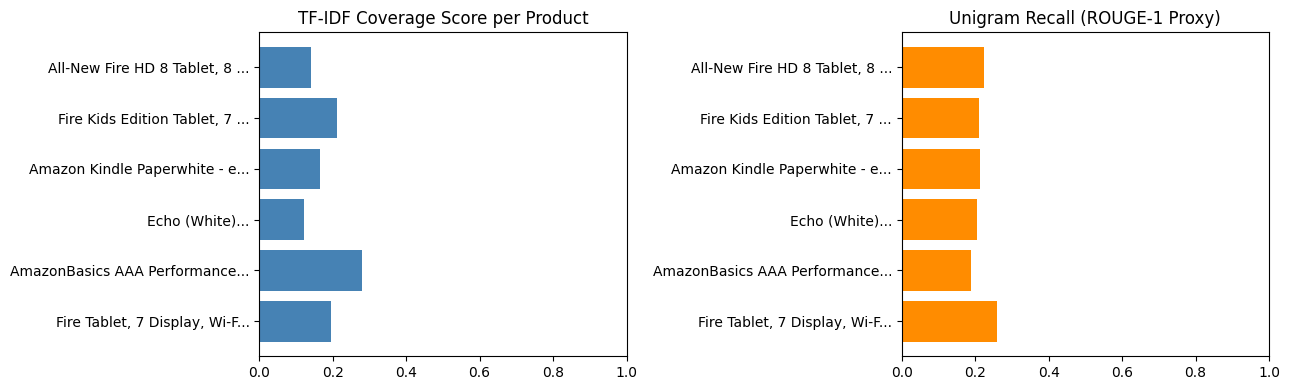

LLM Foundation evaluation complete.


In [ ]:
def tfidf_coverage(original_reviews, summary):
    """TF-IDF cosine similarity between reviews and summary. Proxy for content coverage."""
    original_text = ' '.join(original_reviews)
    if not summary or not original_text: return 0.0
    vec = TfidfVectorizer(stop_words='english', max_features=500)
    try:
        mat = vec.fit_transform([original_text, summary])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

def unigram_recall(original_reviews, summary):
    """Fraction of review words appearing in summary. Proxy for ROUGE-1 recall."""
    if not summary: return 0.0
    orig_words    = set(' '.join(original_reviews).lower().split())
    summ_words    = set(summary.lower().split())
    return round(len(orig_words & summ_words) / len(orig_words) if orig_words else 0, 4)

eval_rows = []
for product in top_products:
    sampled = sample_reviews_for_product(df_work, product)
    summary = summaries.get(product, '')
    eval_rows.append({
        'Product':         product[:45],
        'Total Reviews':   len(df_work[df_work['name'] == product]),
        'Avg Rating':      round(df_work[df_work['name'] == product]['rating'].mean(), 2),
        'TF-IDF Coverage': tfidf_coverage(sampled, summary),
        'Unigram Recall':  unigram_recall(sampled, summary),
        'Summary Words':   len(summary.split()) if summary else 0
    })

eval_df1 = pd.DataFrame(eval_rows)
display(eval_df1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
short = [p[:28] + '...' for p in eval_df1['Product']]
axes[0].barh(short, eval_df1['TF-IDF Coverage'], color='steelblue')
axes[0].set_title('TF-IDF Coverage Score per Product')
axes[0].set_xlim(0, 1)
axes[1].barh(short, eval_df1['Unigram Recall'], color='darkorange')
axes[1].set_title('Unigram Recall (ROUGE-1 Proxy)')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.savefig('eval_llm_foundation.png', dpi=150, bbox_inches='tight')
plt.show()
print('LLM Foundation evaluation complete.')

---
# Advanced Technique 2: Retrieval Augmented Generation (RAG)

Builds a **ChromaDB vector store** from real review data.
For each query, retrieves the most semantically relevant review chunks
and passes them as context to Llama — grounding answers in actual customer language.

- Embedding model: `all-MiniLM-L6-v2` (384-dim dense vectors)
- Comparison: RAG answer vs baseline (no retrieval)

In [ ]:
def build_rag_documents(df, top_n_products=8, reviews_per_product=40):
    """
    Builds two document types per product:
    1. Product stats (avg rating, review count, % positive)
    2. Individual review chunks (balanced positive/negative)
    """
    top_prods = df['name'].value_counts().head(top_n_products).index.tolist()
    documents = []
    for product in top_prods:
        prod_df    = df[df['name'] == product].copy()
        avg_rating = prod_df['rating'].mean()
        total      = len(prod_df)
        pct_pos    = (prod_df['rating'] >= 4).mean() * 100
        cat = prod_df['primaryCategories'].dropna().iloc[0] if 'primaryCategories' in prod_df and prod_df['primaryCategories'].notna().any() else 'Amazon'
        documents.append({
            'doc_id': f'stats_{product[:20].replace(" ","_")}',
            'doc_type': 'product_stats',
            'product': product,
            'text': f'Product: {product}. Category: {cat}. Total reviews: {total}. '
                    f'Average rating: {avg_rating:.2f}/5. Positive reviews: {pct_pos:.1f}%.'
        })
        pos_s = prod_df[prod_df['rating'] >= 4].sample(min(reviews_per_product//2, len(prod_df[prod_df['rating'] >= 4])), random_state=42)
        neg_s = prod_df[prod_df['rating'] <= 2].sample(min(reviews_per_product//4, len(prod_df[prod_df['rating'] <= 2])), random_state=42)
        for idx, row in pd.concat([pos_s, neg_s]).iterrows():
            documents.append({
                'doc_id': f'review_{idx}',
                'doc_type': 'review',
                'product': product,
                'text': f'Product: {product[:60]}. Rating: {row["rating"]}/5. Review: {str(row["review_text"])[:300]}'
            })
    return documents


print('Loading sentence embedding model...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('Building RAG documents...')
rag_docs = build_rag_documents(df_all)

# Build ChromaDB vector store
chroma_client = chromadb.EphemeralClient()
try: chroma_client.delete_collection('amazon_reviews_kb')
except: pass
collection = chroma_client.create_collection('amazon_reviews_kb', metadata={'hnsw:space': 'cosine'})

texts     = [d['text']     for d in rag_docs]
ids       = [d['doc_id']   for d in rag_docs]
metadatas = [{'doc_type': d['doc_type'], 'product': d['product'][:80]} for d in rag_docs]

# Batch embed
BATCH, all_embs = 64, []
for i in range(0, len(texts), BATCH):
    all_embs.extend(embedder.encode(texts[i:i+BATCH]).tolist())
collection.add(documents=texts, embeddings=all_embs, ids=ids, metadatas=metadatas)
print(f'Vector store ready: {collection.count()} documents indexed')

Loading sentence embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Building RAG documents...
Vector store ready: 248 documents indexed


In [ ]:
def retrieve(query, top_k=5):
    """Retrieves top_k most semantically similar review chunks for a query."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    retrieved = []
    for doc, dist, meta in zip(results['documents'][0], results['distances'][0], results['metadatas'][0]):
        retrieved.append({'text': doc, 'similarity': round(1 - dist, 4), 'doc_type': meta['doc_type']})
    return retrieved


def rag_answer(query, top_k=5):
    """Full RAG pipeline: retrieve relevant chunks → build augmented prompt → Llama generates answer."""
    context_docs = retrieve(query, top_k)
    context_text = '\n\n'.join([f'[Source {i+1} | Similarity: {d["similarity"]}]\n{d["text"]}'
                                 for i, d in enumerate(context_docs)])
    system = 'You are an e-commerce analyst. Answer using ONLY the provided review context. Never fabricate facts.'
    prompt = f'Context:\n{context_text}\n\nQuestion: {query}\n\nAnswer:'
    return {'answer': call_llama(prompt, system_prompt=system, temperature=0.3), 'retrieved': context_docs}


def baseline_answer(query):
    """Baseline: Llama answers with no retrieved context."""
    return call_llama(query, system_prompt='You are an e-commerce assistant.', temperature=0.3)


# Run 5 test queries
test_queries = [
    'What do customers say about Fire tablet battery life?',
    'What are the most common complaints about Amazon Echo?',
    'Which product has the highest customer satisfaction and why?',
    'What do negative reviews say about Kindle Paperwhite?',
    'Are Amazon alkaline batteries considered good value for money?'
]

rag_eval_results = []
for query in test_queries:
    print(f'Query: {query}')
    rag_out  = rag_answer(query)
    base_out = baseline_answer(query)
    top_sim  = rag_out['retrieved'][0]['similarity'] if rag_out['retrieved'] else 0
    print(f'  Top similarity: {top_sim}')
    print(f'  RAG:      {(rag_out["answer"] or "")[:200]}')
    print(f'  Baseline: {(base_out or "")[:200]}\n')
    rag_eval_results.append({'query': query, 'rag_answer': rag_out['answer'],
                             'baseline_answer': base_out, 'top_similarity': top_sim,
                             'retrieved': rag_out['retrieved']})

Query: What do customers say about Fire tablet battery life?
  Top similarity: 0.6029
  RAG:      Based on the provided context, there is no direct information about customers' experiences with the Fire tablet battery life. However, there are two reviews that mention issues with charging:

1. Sour
  Baseline: Based on customer reviews and feedback, here's a summary of what customers say about Fire tablet battery life:

1. **Mixed opinions**: Some customers report that the battery life is decent, lasting ar

Query: What are the most common complaints about Amazon Echo?
  Top similarity: 0.6296
  RAG:      Based on the provided reviews, the most common complaints about Amazon Echo are:

1. Random sound cuts-off when connected to a TV as a Bluetooth speaker (Source 1).
2. Unintended shutdowns or cut-offs
  Baseline: As an e-commerce assistant, I've compiled a list of common complaints about Amazon Echo:

1. **Audio Quality Issues**: Some users have reported poor audio quality, such as dis

,Query,Top Similarity,RAG Specificity,Base Specificity,Groundedness
0,What do customers say about Fire table...,0.6029,0.6690,0.7773,0.1687
1,What are the most common complaints ab...,0.6296,0.5772,0.7943,0.1242
2,Which product has the highest customer...,0.4134,0.7620,0.8111,0.6524
3,What do negative reviews say about Kin...,0.8063,0.6241,0.7333,0.2342
4,Are Amazon alkaline batteries consider...,0.6587,0.5924,0.7444,0.3352


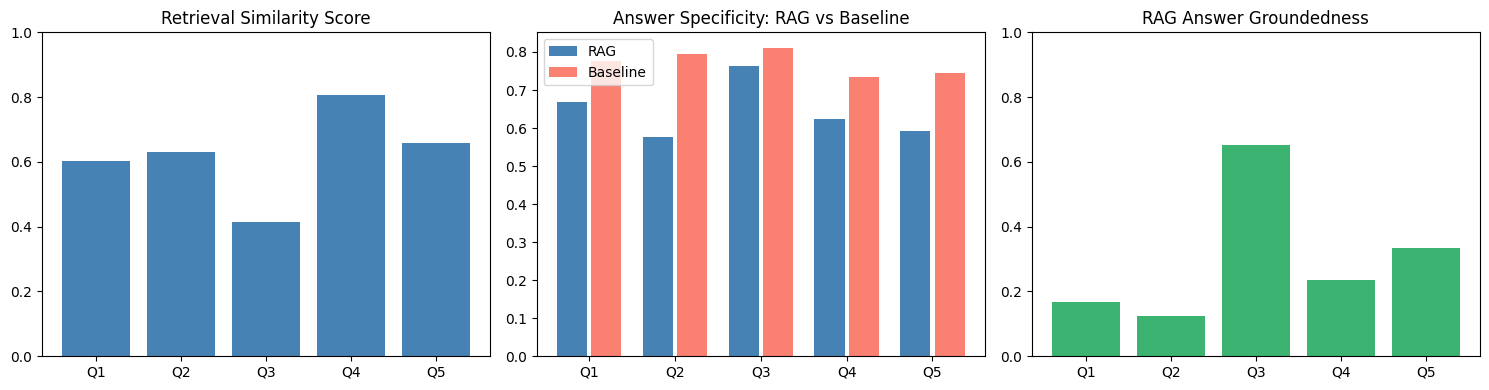

RAG evaluation complete.


In [ ]:
# Evaluation: RAG vs Baseline
def answer_specificity(text):
    """Proxy for specificity: unique-word ratio + normalised length."""
    if not text: return 0.0
    words = text.lower().split()
    return round((len(set(words))/len(words) + min(len(words)/150, 1.0)) / 2, 4)

def data_groundedness(answer, retrieved_docs):
    """TF-IDF overlap between answer and retrieved context — higher = more grounded."""
    if not answer or not retrieved_docs: return 0.0
    ctx = ' '.join([d['text'] for d in retrieved_docs])
    vec = TfidfVectorizer(stop_words='english')
    try:
        mat = vec.fit_transform([ctx, answer])
        return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]), 4)
    except: return 0.0

rag_eval_df = pd.DataFrame([{
    'Query':            r['query'][:38] + '...',
    'Top Similarity':   r['top_similarity'],
    'RAG Specificity':  answer_specificity(r['rag_answer']),
    'Base Specificity': answer_specificity(r['baseline_answer']),
    'Groundedness':     data_groundedness(r['rag_answer'], r['retrieved'])
} for r in rag_eval_results])
display(rag_eval_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
qlabels = [f'Q{i+1}' for i in range(len(rag_eval_df))]
x = np.arange(len(qlabels))
axes[0].bar(qlabels, rag_eval_df['Top Similarity'], color='steelblue')
axes[0].set_title('Retrieval Similarity Score')
axes[0].set_ylim(0, 1)
axes[1].bar(x-.2, rag_eval_df['RAG Specificity'], .35, label='RAG', color='steelblue')
axes[1].bar(x+.2, rag_eval_df['Base Specificity'], .35, label='Baseline', color='salmon')
axes[1].set_xticks(x); axes[1].set_xticklabels(qlabels)
axes[1].set_title('Answer Specificity: RAG vs Baseline')
axes[1].legend()
axes[2].bar(qlabels, rag_eval_df['Groundedness'], color='mediumseagreen')
axes[2].set_title('RAG Answer Groundedness')
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig('eval_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('RAG evaluation complete.')

---
# Advanced Technique 3: Prompting Engineering + Chain-of-Thought (CoT)

Compares three prompt strategies for **fake review detection**:
1. **Simple prompt** – direct ask, no guidance
2. **Instruction prompt** – explicit criteria given
3. **Chain-of-Thought (CoT)** – step-by-step reasoning before verdict

Also applies **instruction prompting** for aspect-based sentiment analysis.

In [ ]:
# Derive heuristic fake signals from real data
def rep_ratio(text):
    words = text.lower().split()
    return round(1 - len(set(words))/len(words), 3) if words else 0

df_flagged = df_all.copy()
df_flagged['rep_ratio']  = df_flagged['review_text'].apply(rep_ratio)
df_flagged['suspicious'] = (
    (df_flagged['word_count'] < 15) &
    (df_flagged['rating'].isin([1.0, 5.0])) &
    (df_flagged['rep_ratio'] > 0.3)
).astype(int)

# Build labelled evaluation sample
fake_s    = df_flagged[df_flagged['suspicious']==1].sample(min(12, df_flagged['suspicious'].sum()), random_state=42)
genuine_s = df_flagged[(df_flagged['suspicious']==0) & (df_flagged['word_count']>=25) & (df_flagged['rep_ratio']<0.2)].sample(12, random_state=42)
fake_s['heuristic_label']    = 'Likely Fake'
genuine_s['heuristic_label'] = 'Likely Genuine'
eval_sample = pd.concat([fake_s, genuine_s]).reset_index(drop=True)

print(f'Fake signals: {df_flagged["suspicious"].sum():,} reviews flagged ({df_flagged["suspicious"].mean()*100:.1f}%)')
print(f'Eval sample: {len(eval_sample)} reviews')
print(eval_sample['heuristic_label'].value_counts())

Fake signals: 10 reviews flagged (0.0%)
Eval sample: 22 reviews
heuristic_label
Likely Genuine    12
Likely Fake       10
Name: count, dtype: int64


In [ ]:
# Three prompt strategies
def prompt_simple(text, rating, wc):
    return f'Review: "{text[:300]}"\nRating: {rating}/5 | Words: {wc}\n\nIs this review fake? Answer: FAKE or GENUINE'

def prompt_instruction(text, rating, wc, rep):
    return f"""You are a fake review detector. Use these criteria:
- Is text too short to be informative (<15 words)?
- Is language vague, generic, or repetitive?
- Is rating extreme (1 or 5★) with little justification?
- Does review mention specific product features?

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition ratio: {rep}

Classification (FAKE or GENUINE only):"""

def prompt_cot(text, rating, wc, rep, username):
    return f"""You are an expert fake review analyst. Think step by step.

Review: "{text[:300]}"
Rating: {rating}/5 | Words: {wc} | Repetition: {rep} | User: {username}

Step 1 – Length & detail: Is the review long enough and specific?
Step 2 – Language: Is it generic, repetitive, or natural?
Step 3 – Rating consistency: Does the star rating match the text tone?
Step 4 – Reviewer signals: Any credibility concerns?
Step 5 – Final assessment.

VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]
REASON: [one sentence]"""

def extract_verdict(response, style):
    """Parses FAKE/GENUINE verdict from model output."""
    if not response: return 'UNKNOWN'
    ru = response.upper()
    if style == 'cot':
        m = re.search(r'VERDICT:\s*(FAKE|GENUINE)', ru)
        if m: return m.group(1)
    if 'FAKE' in ru and 'GENUINE' not in ru: return 'FAKE'
    if 'GENUINE' in ru: return 'GENUINE'
    if 'FAKE' in ru: return 'FAKE'
    return 'UNKNOWN'

print('Prompt templates defined. Running detection...')
SYS = 'You are an expert at detecting fake online product reviews.'
cot_det_results = []

for _, row in eval_sample.iterrows():
    text     = str(row['review_text'])
    rating   = row['rating']
    wc       = row['word_count']
    rep      = row['rep_ratio']
    username = str(row['username']) if 'username' in row.index and pd.notna(row.get('username')) else 'unknown'
    true_lbl = row['heuristic_label']

    r_s = call_llama(prompt_simple(text, rating, wc), SYS, temperature=0.1)
    r_i = call_llama(prompt_instruction(text, rating, wc, rep), SYS, temperature=0.1)
    r_c = call_llama(prompt_cot(text, rating, wc, rep, username), SYS, temperature=0.1)

    cot_det_results.append({
        'true_label':    true_lbl,
        'simple':        extract_verdict(r_s, 'simple'),
        'instruction':   extract_verdict(r_i, 'instruction'),
        'cot':           extract_verdict(r_c, 'cot'),
        'cot_reasoning': r_c,
        'review_text':   text[:80]
    })

cot_res_df = pd.DataFrame(cot_det_results)
print('Detection complete.')
display(cot_res_df[['true_label','simple','instruction','cot','review_text']].head(10))

Prompt templates defined. Running detection...
Groq API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kshzyg83f8ab7wtfg7rrwtkt` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5326, Requested 717. Please try again in 430ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Groq API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kshzyg83f8ab7wtfg7rrwtkt` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5343, Requested 736. Please try again in 790ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Detection complete.


,true_label,simple,instruction,cot,review_text
0,Likely Fake,FAKE,FAKE,FAKE,I have time to do what I have to do just becau...
1,Likely Fake,GENUINE,FAKE,FAKE,Thank you for the gifts and thank you for the ...
2,Likely Fake,GENUINE,FAKE,FAKE,Love it love it love it love it love it love i...
3,Likely Fake,GENUINE,FAKE,GENUINE,I Luke it a lot and good to for it for and goo...
4,Likely Fake,GENUINE,FAKE,GENUINE,Dad loves it love love love it love it love it...
5,Likely Fake,GENUINE,FAKE,GENUINE,Great value. Easy to use. Fun to use. Easy to ...
6,Likely Fake,GENUINE,UNKNOWN,GENUINE,I love everything about it I really enjoy it I...
7,Likely Fake,GENUINE,FAKE,FAKE,"Works Great , Great Item , Easy to Use & Easy ..."
8,Likely Fake,GENUINE,FAKE,FAKE,"Very good price and very good and nice table, ..."
9,Likely Fake,GENUINE,FAKE,FAKE,great tablet and very easy to use. very easy t...


,Accuracy,Precision,Recall,F1
Simple,0.545,0.500,0.1,0.167
Instruction,0.900,0.818,1.0,0.900
Chain-of-Thought,0.591,0.545,0.6,0.571


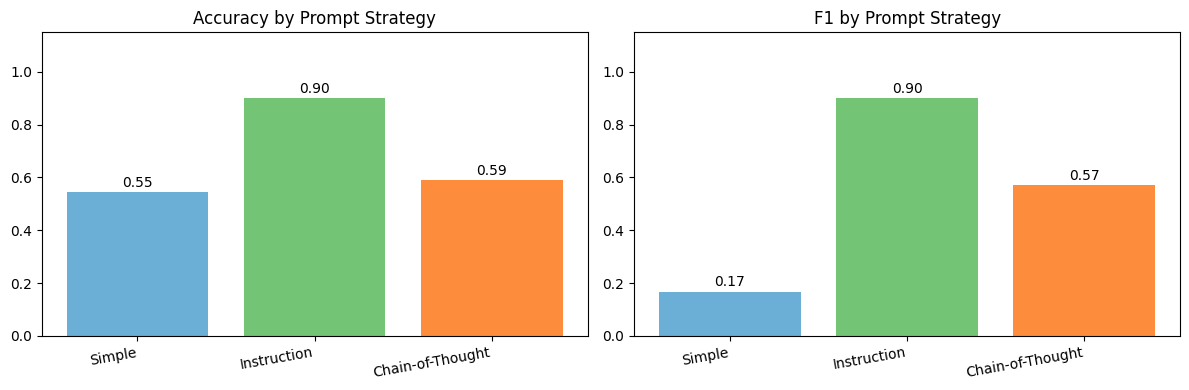

In [ ]:
# Evaluate all three prompt strategies
def evaluate_detection(df, pred_col):
    label_map = {'Likely Fake': 'FAKE', 'Likely Genuine': 'GENUINE'}
    valid = df[df[pred_col] != 'UNKNOWN'].copy()
    valid['true_mapped'] = valid['true_label'].map(label_map)
    correct = (valid[pred_col] == valid['true_mapped']).sum()
    acc = correct / len(valid) if len(valid) else 0
    tp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='FAKE')).sum()
    fp = ((valid[pred_col]=='FAKE') & (valid['true_mapped']=='GENUINE')).sum()
    fn = ((valid[pred_col]=='GENUINE') & (valid['true_mapped']=='FAKE')).sum()
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec  = tp/(tp+fn) if (tp+fn) else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return {'Accuracy': round(acc,3), 'Precision': round(prec,3), 'Recall': round(rec,3), 'F1': round(f1,3)}

perf = {'Simple': evaluate_detection(cot_res_df,'simple'),
        'Instruction': evaluate_detection(cot_res_df,'instruction'),
        'Chain-of-Thought': evaluate_detection(cot_res_df,'cot')}
perf_df = pd.DataFrame(perf).T
display(perf_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#6baed6','#74c476','#fd8d3c']
for ax, metric in zip(axes, ['Accuracy','F1']):
    vals = [perf[m][metric] for m in perf]
    bars = ax.bar(list(perf.keys()), vals, color=colors)
    ax.set_title(f'{metric} by Prompt Strategy')
    ax.set_ylim(0, 1.15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.2f}', ha='center')
    ax.set_xticklabels(list(perf.keys()), rotation=10, ha='right')
plt.tight_layout()
plt.savefig('eval_cot_prompting.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Aspect-Based Sentiment Analysis (Instruction Prompting)

Electronics reviews selected: 15
name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                     4
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta    2
Brand New Amazon Kindle Fire 16gb 7" Ips Display Tablet Wifi 16 Gb Blue                    2
All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case            1
Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen                            1
Name: count, dtype: int64


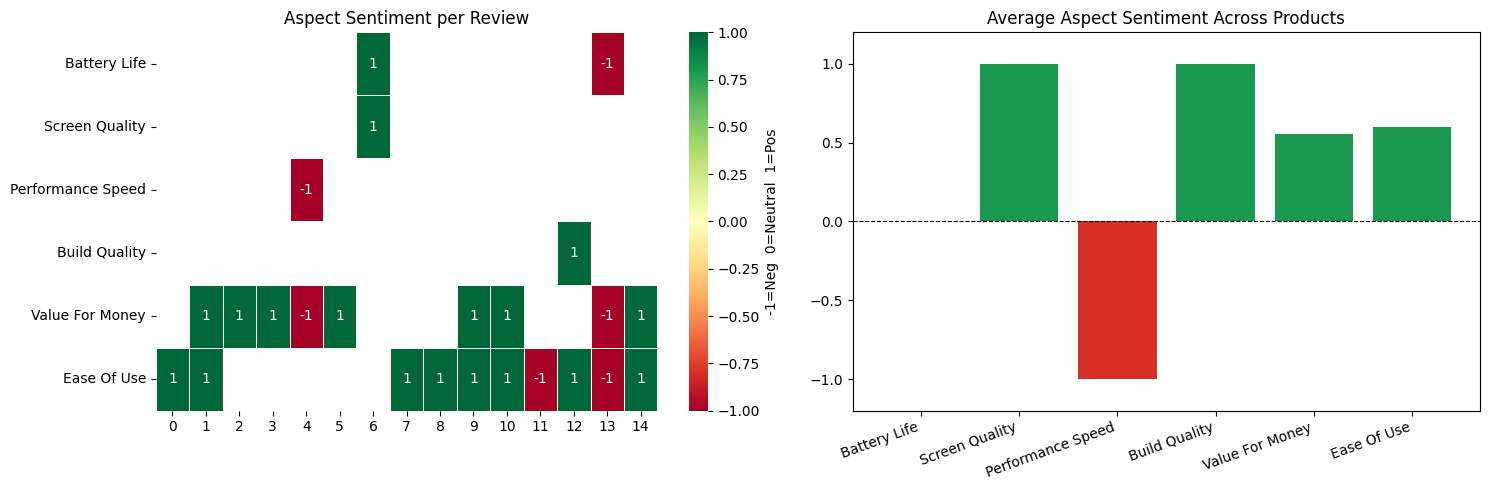

Aspect sentiment analysis complete.


In [ ]:
# Select electronics reviews and sample from that filtered subset
electronics_mask = df_all['name'].str.lower().str.contains('fire|kindle|echo|alexa|tablet|ebook', na=False)
electronics      = df_all[electronics_mask].copy().reset_index(drop=True)
electronics      = electronics.sample(min(15, len(electronics)), random_state=42).reset_index(drop=True)

print(f'Electronics reviews selected: {len(electronics)}')
print(electronics['name'].value_counts().head(5))

ASPECTS  = ['battery_life','screen_quality','performance_speed','build_quality','value_for_money','ease_of_use']
SENT_MAP = {'Positive':1, 'Neutral':0, 'Negative':-1, 'Not_Mentioned': None}
asp_results = []

for _, row in electronics.iterrows():
    prompt = f"""Review: "{str(row['review_text'])[:400]}"
Extract sentiment for each aspect: Positive, Negative, Neutral, or Not_Mentioned.
Respond ONLY as JSON:
{{"battery_life":"...","screen_quality":"...","performance_speed":"...","build_quality":"...","value_for_money":"...","ease_of_use":"..."}}"""
    response = call_llama(prompt, temperature=0.1)
    try:
        jm = re.search(r'\{.*\}', response or '', re.DOTALL)
        parsed = json.loads(jm.group()) if jm else {}
    except Exception:
        parsed = {}
    row_data = {'product': row['name'][:40], 'rating': row['rating']}
    for asp in ASPECTS:
        row_data[asp] = SENT_MAP.get(parsed.get(asp, 'Not_Mentioned'), None)
    asp_results.append(row_data)

asp_df = pd.DataFrame(asp_results)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(asp_df[ASPECTS].astype(float).T, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.0f', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
axes[0].set_title('Aspect Sentiment per Review')
axes[0].set_yticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=0)
avg_asp = {a: asp_df[a].dropna().mean() for a in ASPECTS}
cols    = ['#1a9850' if v > 0.1 else '#d73027' if v < -0.1 else '#fdae61' for v in avg_asp.values()]
axes[1].bar([a.replace('_',' ').title() for a in ASPECTS], list(avg_asp.values()), color=cols)
axes[1].set_title('Average Aspect Sentiment Across Products')
axes[1].set_ylim(-1.2, 1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels([a.replace('_',' ').title() for a in ASPECTS], rotation=20, ha='right')
plt.tight_layout()
plt.savefig('eval_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Aspect sentiment analysis complete.')


---
# Advanced Technique 4: Agentic Design

An autonomous agent that **plans** which tools to run and **executes** them in sequence:
- **Tool A** – Fake detector (CoT prompting)
- **Tool B** – Sentiment analyser (instruction prompting)
- **Tool C** – RAG retriever (semantic search on reviews)
- **Tool D** – Report generator (Llama summarisation)

This ties all 4 advanced techniques into a single unified pipeline.

In [ ]:
# ═══ TOOL A: Fake Detector ═══════════════════════════════════════════════
def tool_fake_detector(reviews_df):
    """Flags suspicious reviews using heuristics + LLM CoT on top candidates."""
    df = reviews_df.copy()
    total = len(df)

    # Recalculate fake signals on whatever df is passed in
    if 'word_count' not in df.columns:
        df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
    def _rep(text):
        w = str(text).lower().split()
        return round(1 - len(set(w))/len(w), 3) if w else 0
    df['rep_ratio']  = df['review_text'].apply(_rep)
    df['suspicious'] = (
        (df['word_count'] < 15) &
        (df['rating'].isin([1.0, 5.0])) &
        (df['rep_ratio'] > 0.3)
    ).astype(int)

    h_flags        = int(df['suspicious'].sum())
    top_suspicious = df[df['suspicious'] == 1].head(5)
    llm_flags = []

    for _, row in top_suspicious.iterrows():
        prompt = f"""Review: "{str(row['review_text'])[:250]}"
Rating: {row['rating']}/5 | Words: {row['word_count']}
Step 1: Is it too short? Step 2: Generic language? Step 3: Rating justified?
VERDICT: [FAKE or GENUINE]
CONFIDENCE: [Low/Medium/High]"""
        resp = call_llama(prompt, 'You are a fake review expert.', temperature=0.1) or ''
        vm   = re.search(r'VERDICT:\s*(FAKE|GENUINE)', resp.upper())
        cm   = re.search(r'CONFIDENCE:\s*(\w+)', resp, re.IGNORECASE)
        llm_flags.append({
            'review':     str(row['review_text'])[:80],
            'verdict':    vm.group(1) if vm else 'UNKNOWN',
            'confidence': cm.group(1) if cm else 'Unknown'
        })

    return {
        'total_reviews':        total,
        'heuristic_suspicious': h_flags,
        'llm_confirmed_fake':   sum(1 for f in llm_flags if f['verdict'] == 'FAKE'),
        'fake_rate_pct':        round(h_flags / total * 100, 1),
        'flagged_details':      llm_flags
    }


# ═══ TOOL B: Sentiment Analyser ══════════════════════════════════════════════
def tool_sentiment_analyser(reviews_df, n_sample=10):
    """Extracts overall stats and aspect-level sentiment for a product."""
    sample     = reviews_df[reviews_df['word_count'] >= 15].sample(
                     min(n_sample, len(reviews_df[reviews_df['word_count'] >= 15])), random_state=42)
    avg_r      = reviews_df['rating'].mean()
    pct_pos    = (reviews_df['rating'] >= 4).mean() * 100
    pct_neg    = (reviews_df['rating'] <= 2).mean() * 100
    aspects    = ['battery_life', 'performance', 'build_quality', 'value', 'usability']
    asp_totals = {a: [] for a in aspects}
    s_map      = {'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Not_Mentioned': None}

    for _, row in sample.iterrows():
        prompt = (f'Review: "{str(row["review_text"])[:300]}"\n'
                  f'For each aspect give: Positive/Negative/Neutral/Not_Mentioned.\n'
                  f'JSON only: {{"battery_life":"...","performance":"...","build_quality":"...","value":"...","usability":"..."}}' )
        resp = call_llama(prompt, 'You are a sentiment analyst.', temperature=0.1)
        try:
            jm     = re.search(r'\{.*\}', resp or '', re.DOTALL)
            parsed = json.loads(jm.group()) if jm else {}
        except Exception:
            parsed = {}
        for asp in aspects:
            v = s_map.get(parsed.get(asp, 'Not_Mentioned'), None)
            if v is not None:
                asp_totals[asp].append(v)

    return {
        'avg_rating':    round(avg_r, 2),
        'pct_positive':  round(pct_pos, 1),
        'pct_negative':  round(pct_neg, 1),
        'aspect_scores': {a: round(np.mean(v), 3) if v else 0.0 for a, v in asp_totals.items()}
    }


# ═══ TOOL C: RAG Retriever ════════════════════════════════════════════════════
def tool_rag_retriever(query, top_k=4):
    """Uses the ChromaDB collection built in Section 2 for retrieval."""
    q_emb   = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k)
    return '\n\n'.join(results['documents'][0])


# ═══ TOOL D: Report Generator ═════════════════════════════════════════════════
def tool_report_generator(product_name, fake_r, sent_r, rag_ctx):
    """Synthesises all tool outputs into a structured business report via Llama."""
    system = 'You are a senior e-commerce business analyst. Be concise and data-driven.'
    prompt = (f'Product: {product_name[:70]}\n'
              f'REVIEW AUTHENTICITY: {fake_r["heuristic_suspicious"]} suspicious / '
              f'{fake_r["total_reviews"]} total ({fake_r["fake_rate_pct"]}%)\n'
              f'SENTIMENT: Avg {sent_r["avg_rating"]}★ | {sent_r["pct_positive"]}% positive | '
              f'{sent_r["pct_negative"]}% negative\n'
              f'ASPECT SCORES: {sent_r["aspect_scores"]}\n'
              f'CUSTOMER CONTEXT (from reviews):\n{rag_ctx[:600]}\n\n'
              f'Write a business intelligence report:\n'
              f'1. Product Health Score (1-10)\n'
              f'2. Review Authenticity Assessment\n'
              f'3. Top 2 customer strengths\n'
              f'4. Top 2 customer pain points\n'
              f'5. Three specific seller recommendations')
    return call_llama(prompt, system_prompt=system, temperature=0.3)


print('All 4 agent tools defined.')


All 4 agent tools defined.


In [ ]:
from datetime import datetime

class EcommerceAgent:
    """
    Autonomous e-commerce intelligence agent.
    Follows a ReAct-style loop:
    Observe (product + reviews) → Think (plan tools) → Act (run tools) → Report
    """
    def __init__(self): self.log = []

    def _log(self, step, tool, summary):
        entry = {'step': step, 'tool': tool, 'summary': str(summary)[:100],
                 'time': datetime.now().strftime('%H:%M:%S')}
        self.log.append(entry)
        print(f'  [{entry["time"]}] Step {step} | {tool} → {str(summary)[:70]}')

    def plan(self, product_name, n_reviews):
        """Uses Llama to decide which tools to run and in what order."""
        prompt = f"""Task: Analyse '{product_name[:50]}' with {n_reviews} reviews.
Available tools: [fake_detector, sentiment_analyser, rag_retriever, report_generator]
List tools in execution order (one per line, names only):"""
        resp = call_llama(prompt, temperature=0.1) or ''
        tool_map = {'fake':'fake_detector','sentiment':'sentiment_analyser',
                    'rag':'rag_retriever','report':'report_generator'}
        plan = []
        for line in resp.split('\n'):
            for key, name in tool_map.items():
                if key in line.lower() and name not in plan:
                    plan.append(name)
        if not plan or 'report_generator' not in plan:
            plan = ['fake_detector','sentiment_analyser','rag_retriever','report_generator']
        elif plan[-1] != 'report_generator':
            plan = [t for t in plan if t != 'report_generator'] + ['report_generator']
        return plan

    def run(self, product_name, full_df):
        """Runs the full plan-and-execute loop for a single product."""
        self.log = []
        prod_df  = full_df[full_df['name'].str.contains(product_name[:30], case=False, na=False)].copy()
        if prod_df.empty:
            print(f'No reviews found for: {product_name}')
            return None

        print(f'\n{"="*65}')
        print(f'Agent: {product_name[:60]}')
        print(f'Reviews: {len(prod_df)} | {"="*30}')

        plan  = self.plan(product_name, len(prod_df))
        print(f'Plan: {plan}')

        step = 1
        fake_r, sent_r, rag_ctx, report = None, None, '', ''

        for tool in plan:
            if tool == 'fake_detector':
                fake_r = tool_fake_detector(prod_df)
                self._log(step, tool, f"{fake_r['heuristic_suspicious']} suspicious / {fake_r['total_reviews']} total")
            elif tool == 'sentiment_analyser':
                sent_r = tool_sentiment_analyser(prod_df)
                self._log(step, tool, f"Avg {sent_r['avg_rating']}★ | {sent_r['pct_positive']}% positive")
            elif tool == 'rag_retriever':
                rag_ctx = tool_rag_retriever(f'{product_name} customer feedback issues')
                self._log(step, tool, f'Retrieved {len(rag_ctx.split())} words')
            elif tool == 'report_generator' and fake_r and sent_r:
                report = tool_report_generator(product_name, fake_r, sent_r, rag_ctx)
                self._log(step, tool, 'Report generated')
            step += 1

        return {'product': product_name, 'n_reviews': len(prod_df), 'plan': plan,
                'fake_r': fake_r, 'sent_r': sent_r, 'report': report, 'agent_log': self.log}


# Run agent on top 3 products
agent       = EcommerceAgent()
top_3       = df_all['name'].value_counts().head(3).index.tolist()
all_outputs = []
for product in top_3:
    out = agent.run(product, df_all)
    if out: all_outputs.append(out)


Agent: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer
Reviews: 12204 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [12:26:29] Step 1 | fake_detector → 7 suspicious / 12204 total
  [12:26:46] Step 2 | sentiment_analyser → Avg 4.46★ | 90.8% positive
  [12:26:46] Step 3 | rag_retriever → Retrieved 118 words
  [12:26:53] Step 4 | report_generator → Report generated

Agent: AmazonBasics AAA Performance Alkaline Batteries (36 Count)
Reviews: 4275 | ==============================
Plan: ['fake_detector', 'sentiment_analyser', 'rag_retriever', 'report_generator']
  [12:26:56] Step 1 | fake_detector → 0 suspicious / 4275 total
  [12:27:12] Step 2 | sentiment_analyser → Avg 4.24★ | 80.1% positive
  [12:27:12] Step 3 | rag_retriever → Retrieved 141 words
  [12:27:18] Step 4 | report_generator → Report generated
No reviews found for: Echo (White)


In [ ]:
# Display intelligence reports
for out in all_outputs:
    display(Markdown(f'---\n## Intelligence Report: {out["product"][:70]}'))
    display(Markdown(out['report'] or '*No report generated*'))

# Agent execution log
print('\n=== Agent Execution Log ===')
for out in all_outputs:
    print(f'\nProduct: {out["product"][:60]}')
    display(pd.DataFrame(out['agent_log'])[['step','tool','time','summary']])

---
## Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta

**Business Intelligence Report: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta**

**1. Product Health Score (1-10)**

Based on the sentiment analysis and aspect scores, I would assign a Product Health Score of 7 out of 10. The product has a high overall positive sentiment (90.8%) and strong performance, build quality, and usability scores. However, the battery life aspect score is 0.0, indicating a significant concern.

**2. Review Authenticity Assessment**

The review authenticity assessment indicates a low level of suspicious reviews (7 out of 12204), which is 0.1%. This suggests that the reviews are generally authentic and trustworthy.

**3. Top 2 Customer Strengths**

Based on the customer context, the top 2 customer strengths are:

1. **Value**: Many customers appreciate the great price of the product, as evident from the 5-star review "great item and at a great price. love using it daily."
2. **Performance**: Some customers praise the product's performance, as seen in the 5-star review "great item and at a great price. love using it daily."

**4. Top 2 Customer Pain Points**

Based on the customer context, the top 2 customer pain points are:

1. **Battery Life**: Several customers have reported issues with the battery life, such as the 1-star review "Honestly the worst tablet ever owned. Was very slow and unreliable would switch off."
2. **Build Quality**: Some customers have experienced issues with the build quality, such as the 2-star review "This product is a great product as long as the plug-in charge port doesn't break and quit taking a charge."

**5. Three Specific Seller Recommendations**

Based on the customer pain points and strengths, I recommend the following:

1. **Improve Battery Life**: Consider upgrading the battery or improving the charging system to address customer concerns about battery life.
2. **Enhance Build Quality**: Implement quality control measures to prevent issues with the charge port and other build quality concerns.
3. **Offer Extended Warranty**: Offer an extended warranty or protection plan to alleviate customer concerns about the product's durability and build quality.

By addressing these concerns and building on the product's strengths, the seller can improve customer satisfaction and increase loyalty.

---
## Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)

**Business Intelligence Report: AmazonBasics AAA Performance Alkaline Batteries (36 Count)**

**1. Product Health Score (1-10)**

Based on the sentiment analysis and aspect scores, I would rate the product health score as 8/10. The product has an average rating of 4.24/5, with 80.1% positive reviews, indicating a high level of customer satisfaction. However, the aspect scores reveal some areas for improvement, particularly in battery life (0.25/1) and usability (0.0/1).

**2. Review Authenticity Assessment**

The review authenticity assessment indicates that 0 out of 4275 reviews are suspicious, which suggests that the reviews are largely genuine. The low suspicious review rate (0.0%) further supports the authenticity of the reviews.

**3. Top 2 Customer Strengths**

Based on the customer reviews, the top 2 customer strengths are:

1. **Value**: Customers appreciate the value offered by the product, with many reviewers mentioning that it is a "real steal" compared to store-bought batteries.
2. **Performance**: Customers are satisfied with the performance of the batteries, with many reviewers mentioning that they are "the RIGHT item delivered FAST at a GOOD price."

**4. Top 2 Customer Pain Points**

Based on the customer reviews, the top 2 customer pain points are:

1. **Battery Life**: Some customers have reported issues with the battery life, which may be a concern for customers who require long-lasting batteries.
2. **Usability**: The aspect score for usability is 0.0/1, indicating that customers may have difficulty using the product or finding it easy to use.

**5. Three Specific Seller Recommendations**

Based on the customer reviews and product health score, I recommend the following:

1. **Improve Battery Life**: Consider improving the battery life of the product to address customer concerns and increase customer satisfaction.
2. **Enhance Usability**: Consider simplifying the packaging or instructions to make it easier for customers to use the product.
3. **Maintain Competitive Pricing**: Continue to offer competitive pricing to customers, as this is a key strength of the product and a major factor in customer satisfaction.

By addressing these areas, the seller can further improve customer satisfaction and maintain a strong market position for the AmazonBasics AAA Performance Alkaline Batteries (36 Count).


=== Agent Execution Log ===

Product: Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offer


,step,tool,time,summary
0,1,fake_detector,12:26:29,7 suspicious / 12204 total
1,2,sentiment_analyser,12:26:46,Avg 4.46★ | 90.8% positive
2,3,rag_retriever,12:26:46,Retrieved 118 words
3,4,report_generator,12:26:53,Report generated



Product: AmazonBasics AAA Performance Alkaline Batteries (36 Count)


,step,tool,time,summary
0,1,fake_detector,12:26:56,0 suspicious / 4275 total
1,2,sentiment_analyser,12:27:12,Avg 4.24★ | 80.1% positive
2,3,rag_retriever,12:27:12,Retrieved 141 words
3,4,report_generator,12:27:18,Report generated


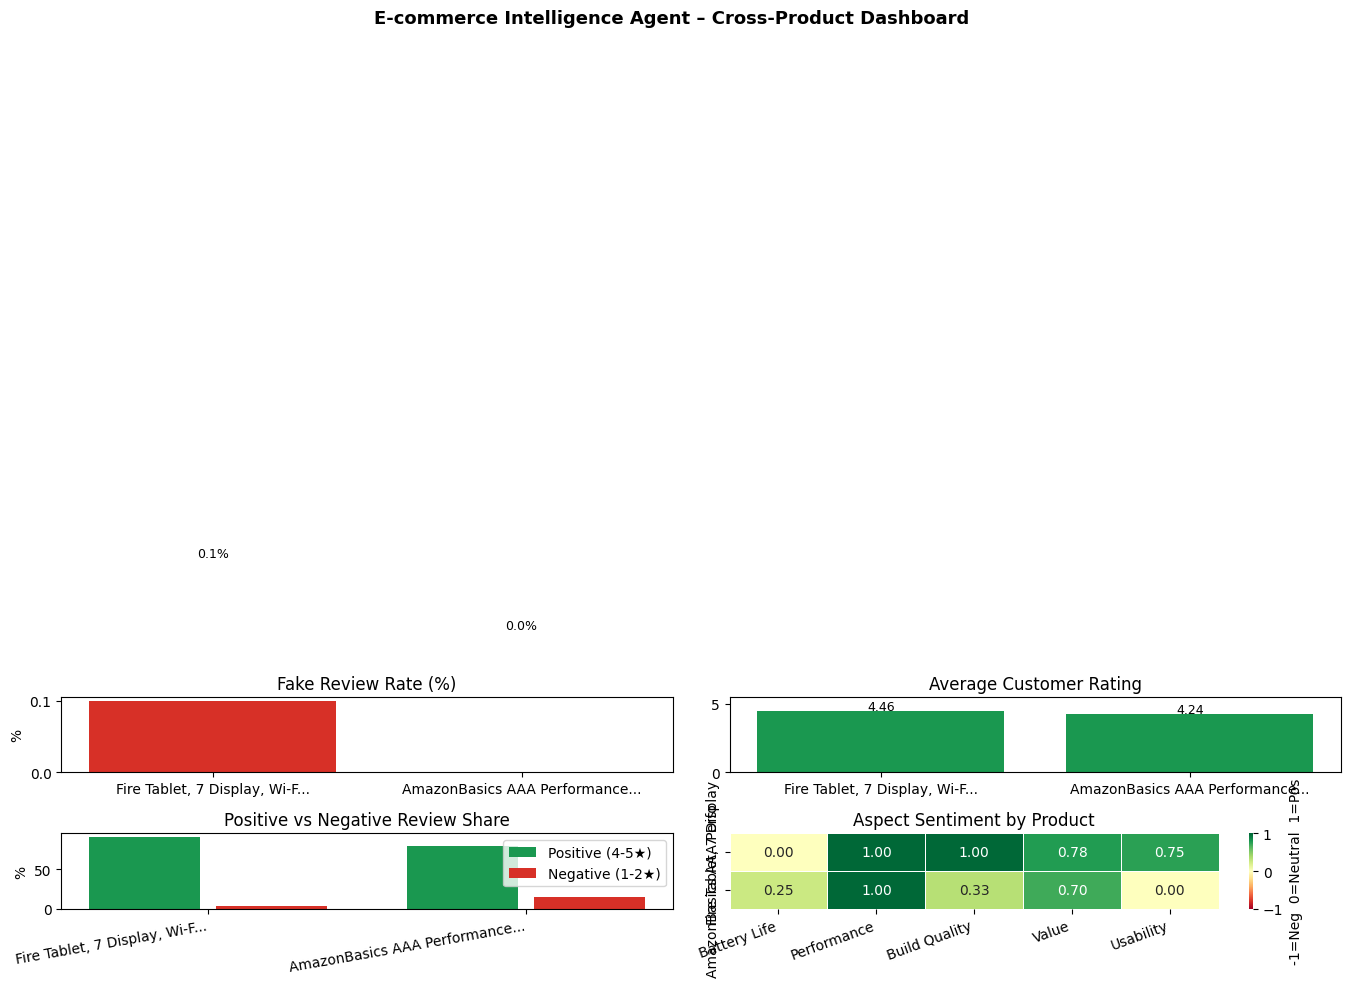

Dashboard saved.


In [ ]:
# Cross-product dashboard
if all_outputs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    p_labels  = [o['product'][:28] + '...' for o in all_outputs]

    fake_rates = [o['fake_r']['fake_rate_pct'] for o in all_outputs if o['fake_r']]
    axes[0,0].bar(p_labels[:len(fake_rates)], fake_rates, color='#d73027')
    axes[0,0].set_title('Fake Review Rate (%)')
    axes[0,0].set_ylabel('%')
    for i,v in enumerate(fake_rates): axes[0,0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)

    avg_ratings = [o['sent_r']['avg_rating'] for o in all_outputs if o['sent_r']]
    bar_colors  = ['#1a9850' if r>=4 else '#fdae61' if r>=3 else '#d73027' for r in avg_ratings]
    axes[0,1].bar(p_labels[:len(avg_ratings)], avg_ratings, color=bar_colors)
    axes[0,1].set_title('Average Customer Rating')
    axes[0,1].set_ylim(0, 5.5)
    for i,v in enumerate(avg_ratings): axes[0,1].text(i, v+0.1, f'{v:.2f}', ha='center', fontsize=9)

    x       = np.arange(len(all_outputs))
    pct_pos = [o['sent_r']['pct_positive'] for o in all_outputs if o['sent_r']]
    pct_neg = [o['sent_r']['pct_negative'] for o in all_outputs if o['sent_r']]
    axes[1,0].bar(x-.2, pct_pos[:len(x)], .35, label='Positive (4-5★)', color='#1a9850')
    axes[1,0].bar(x+.2, pct_neg[:len(x)], .35, label='Negative (1-2★)', color='#d73027')
    axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(p_labels[:len(x)], rotation=10, ha='right')
    axes[1,0].set_title('Positive vs Negative Review Share')
    axes[1,0].set_ylabel('%')
    axes[1,0].legend()

    asp_data = [o['sent_r']['aspect_scores'] for o in all_outputs if o['sent_r']]
    if asp_data:
        asp_plot = pd.DataFrame(asp_data, index=[o['product'][:22] for o in all_outputs[:len(asp_data)]])
        sns.heatmap(asp_plot, cmap='RdYlGn', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
                    linewidths=0.5, ax=axes[1,1], cbar_kws={'label': '-1=Neg  0=Neutral  1=Pos'})
        axes[1,1].set_title('Aspect Sentiment by Product')
        axes[1,1].set_xticklabels([a.replace('_',' ').title() for a in asp_plot.columns], rotation=20, ha='right')

    plt.suptitle('E-commerce Intelligence Agent – Cross-Product Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('agent_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Dashboard saved.')

---
# Project Summary

| Advanced Technique | Implementation | Evaluation Metric |
|---|---|---|
| LLM Foundation (Llama 3.1) | Review summarisation, description generation, business insights | TF-IDF Coverage, Unigram Recall |
| RAG | ChromaDB vector store + sentence-transformers retrieval | Retrieval similarity, Groundedness, Specificity |
| CoT Prompting | Fake detection (3 strategies), aspect sentiment | Accuracy, Precision, Recall, F1 |
| Agentic Design | Plan-and-execute pipeline across all tools | Execution log, Cross-product dashboard |

**Dataset:** Datafiniti Amazon Consumer Reviews (~67,000 reviews combined from 3 CSVs)

**Model:** Llama 3.1-8b-instant via Groq API (free tier)

**Plots saved:** `nb1_rating_distribution.png`, `eval_llm_foundation.png`, `eval_rag.png`, `eval_cot_prompting.png`, `eval_aspect_sentiment.png`, `agent_dashboard.png`